     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 20.1 MB/s eta 0:00:00


Document created: docs/sample_article.txt
Total characters: 1786
Total words: 262

LOADED TXT DOCUMENT
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many example ...

PDF created: docs/sample_article.pdf

PDF DOCUMENT
Pages found: 1

Extracted PDF text preview:

Artificial Intelligence: An Overview
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from

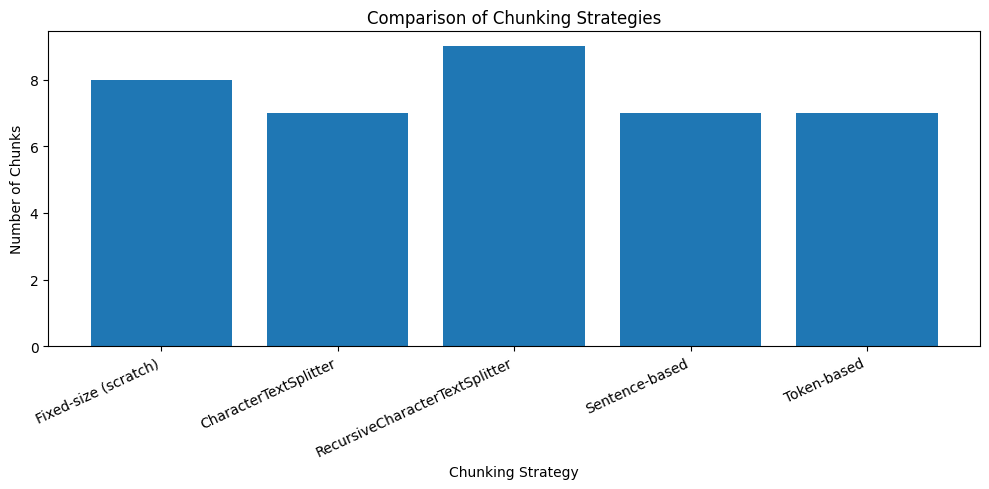


RAG DOCUMENT LOADING AND CHUNKING COMPLETED
1. TXT document loaded successfully
2. PDF document created and loaded successfully
3. Fixed-size chunking completed
4. CharacterTextSplitter completed
5. RecursiveCharacterTextSplitter completed
6. Sentence-based chunking completed
7. Token-based chunking completed
8. All strategies compared successfully


In [2]:
# ============================================================
# RAG STEP 1: DOCUMENT LOADING AND CHUNKING STRATEGIES
# GOOGLE COLAB - COMPLETE CODE
# ============================================================

# Install required libraries
!pip install -q langchain langchain-text-splitters tiktoken pypdf fpdf2

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import re
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt

from fpdf import FPDF
from pypdf import PdfReader

from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

# ============================================================
# 2. CREATE SAMPLE DOCUMENT
# ============================================================

os.makedirs("docs", exist_ok=True)

article_text = """Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence.

Natural Language Processing, or NLP, is the branch of AI that focuses specifically on human
language. NLP powers chatbots, translation tools, and search engines. A key building block of
modern NLP is the embedding, which converts words or sentences into numeric vectors that capture
meaning.

Retrieval-Augmented Generation, or RAG, is a technique that combines a search system with a
language model. Instead of relying only on what a language model memorized during training, RAG
first retrieves relevant, up-to-date information from a document collection, then passes that
information to the model so it can generate a more accurate, grounded answer.

Vector Databases store embeddings and allow fast similarity search across millions of documents.
They are a core infrastructure piece behind modern RAG systems, chatbots, and recommendation
engines used by companies around the world today.
"""

with open("docs/sample_article.txt", "w") as f:
    f.write(article_text)

print("Document created: docs/sample_article.txt")
print("Total characters:", len(article_text))
print("Total words:", len(article_text.split()))

# ============================================================
# 3. LOAD TXT DOCUMENT
# ============================================================

with open("docs/sample_article.txt", "r") as f:
    loaded_text = f.read()

print("\n" + "=" * 60)
print("LOADED TXT DOCUMENT")
print("=" * 60)
print(loaded_text[:500], "...")

# ============================================================
# 4. CREATE SAMPLE PDF
# ============================================================

pdf = FPDF()
pdf.add_page()
pdf.set_font("Times", size=12)

for line in article_text.split("\n"):
    pdf.multi_cell(190, 8, line)

pdf.output("docs/sample_article.pdf")
print("\nPDF created: docs/sample_article.pdf")

# ============================================================
# 5. LOAD PDF DOCUMENT
# ============================================================

reader = PdfReader("docs/sample_article.pdf")
pdf_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        pdf_text += text + "\n"

print("\n" + "=" * 60)
print("PDF DOCUMENT")
print("=" * 60)
print("Pages found:", len(reader.pages))
print("\nExtracted PDF text preview:\n")
print(pdf_text[:500], "...")

# ============================================================
# 6. CHUNKING STRATEGY 1: FIXED-SIZE CHARACTER CHUNKING
# ============================================================

def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

fixed_chunks = fixed_size_chunking(loaded_text, chunk_size=300, overlap=50)

print("\n" + "=" * 60)
print("STRATEGY 1: FIXED-SIZE CHARACTER CHUNKING")
print("=" * 60)
print("Number of chunks:", len(fixed_chunks))

for i, chunk in enumerate(fixed_chunks[:2]):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

# ============================================================
# 7. CHUNKING STRATEGY 2: CHARACTER TEXT SPLITTER
# ============================================================

char_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=300,
    chunk_overlap=50
)

char_chunks = char_splitter.split_text(loaded_text)

print("\n" + "=" * 60)
print("STRATEGY 2: CHARACTER TEXT SPLITTER")
print("=" * 60)
print("Number of chunks:", len(char_chunks))

for i, chunk in enumerate(char_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

# ============================================================
# 8. CHUNKING STRATEGY 3: RECURSIVE CHARACTER TEXT SPLITTER
# ============================================================

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(loaded_text)

print("\n" + "=" * 60)
print("STRATEGY 3: RECURSIVE CHARACTER TEXT SPLITTER")
print("=" * 60)
print("Number of chunks:", len(recursive_chunks))

for i, chunk in enumerate(recursive_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

# ============================================================
# 9. CHUNKING STRATEGY 4: SENTENCE-BASED CHUNKING
# ============================================================

def sentence_chunking(text, sentences_per_chunk=2):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]
    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = " ".join(sentences[i:i + sentences_per_chunk])
        chunks.append(chunk)
    return chunks

sentence_chunks = sentence_chunking(loaded_text, sentences_per_chunk=2)

print("\n" + "=" * 60)
print("STRATEGY 4: SENTENCE-BASED CHUNKING")
print("=" * 60)
print("Number of chunks:", len(sentence_chunks))

for i, chunk in enumerate(sentence_chunks[:4]):
    print(f"\n--- Chunk {i+1} ---")
    print(chunk)

# ============================================================
# 10. CHUNKING STRATEGY 5: TOKEN-BASED CHUNKING
# ============================================================

encoding = tiktoken.get_encoding("cl100k_base")

def token_chunking(text, max_tokens=60, overlap_tokens=10):
    tokens = encoding.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]
        chunks.append(encoding.decode(chunk_tokens))
        start += max_tokens - overlap_tokens
    return chunks

token_chunks = token_chunking(loaded_text, max_tokens=60, overlap_tokens=10)

print("\n" + "=" * 60)
print("STRATEGY 5: TOKEN-BASED CHUNKING")
print("=" * 60)
print("Number of chunks:", len(token_chunks))

for i, chunk in enumerate(token_chunks[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"\n--- Chunk {i+1} ({token_count} tokens) ---")
    print(chunk)

# ============================================================
# 11. COMPARE ALL CHUNKING STRATEGIES
# ============================================================

comparison = pd.DataFrame({
    "Strategy": [
        "Fixed-size (scratch)",
        "CharacterTextSplitter",
        "RecursiveCharacterTextSplitter",
        "Sentence-based",
        "Token-based"
    ],
    "Number of Chunks": [
        len(fixed_chunks),
        len(char_chunks),
        len(recursive_chunks),
        len(sentence_chunks),
        len(token_chunks)
    ],
    "Avg Chunk Length (chars)": [
        round(sum(len(c) for c in fixed_chunks) / len(fixed_chunks), 1),
        round(sum(len(c) for c in char_chunks) / len(char_chunks), 1),
        round(sum(len(c) for c in recursive_chunks) / len(recursive_chunks), 1),
        round(sum(len(c) for c in sentence_chunks) / len(sentence_chunks), 1),
        round(sum(len(c) for c in token_chunks) / len(token_chunks), 1)
    ]
})

# ============================================================
# 12. DISPLAY COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("COMPARISON OF ALL CHUNKING STRATEGIES")
print("=" * 60)
print(comparison.to_string(index=False))

# ============================================================
# 13. SIMPLE BAR CHART
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(comparison["Strategy"], comparison["Number of Chunks"])
plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.title("Comparison of Chunking Strategies")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("RAG DOCUMENT LOADING AND CHUNKING COMPLETED")
print("=" * 60)
print("1. TXT document loaded successfully")
print("2. PDF document created and loaded successfully")
print("3. Fixed-size chunking completed")
print("4. CharacterTextSplitter completed")
print("5. RecursiveCharacterTextSplitter completed")
print("6. Sentence-based chunking completed")
print("7. Token-based chunking completed")
print("8. All strategies compared successfully")
